Loading image captioning model...
Loading question answering model...

    🖼️🤖 Image Analysis Assistant
    

🔊 Assistant: Hello! I'm your image analysis assistant.



Choose image source:
1: Upload from computer
2: Enter image URL
Your choice (1/2): 2

Enter image URL: https://t3.ftcdn.net/jpg/08/00/68/98/360_F_800689824_Z4oDFNUOEUwBZXDcKvaHBjZPSu2tMW1g.jpg


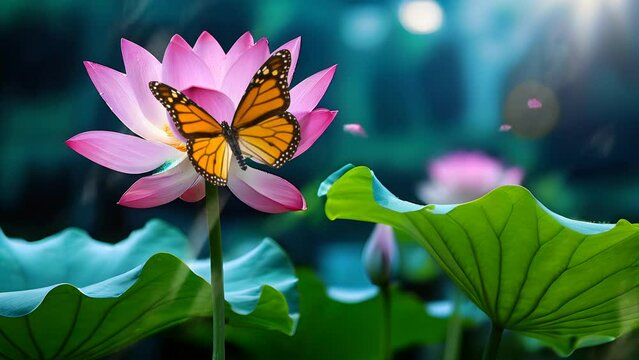


Analyzing image...

📝 Description:
there is a butterfly that is sitting on top of a flower

🔊 Assistant: I see: there is a butterfly that is sitting on top of a flower



Ask questions about the image (say 'exit' to end)

Choose input method:
1: Type
2: Speak
Your choice (1/2): 2


<IPython.core.display.Javascript object>


🎤 Click the 'Stop Recording' button when done...
Recording timed out.

Choose input method:
1: Type
2: Speak
Your choice (1/2): 2


<IPython.core.display.Javascript object>


🎤 Click the 'Stop Recording' button when done...
Recording timed out.

Choose input method:
1: Type
2: Speak
Your choice (1/2): 1

Your question: what is the color of butterfly?

Thinking...

💡 Answer: yellow. there is a butterfly that is sitting on top of a flower

🔊 Assistant: yellow. there is a butterfly that is sitting on top of a flower



Choose input method:
1: Type
2: Speak
Your choice (1/2): 1

Your question: Which type of flower it is ?

Thinking...

💡 Answer: lily. there is a butterfly that is sitting on top of a flower

🔊 Assistant: lily. there is a butterfly that is sitting on top of a flower



Choose input method:
1: Type
2: Speak
Your choice (1/2): 2


<IPython.core.display.Javascript object>


🎤 Click the 'Stop Recording' button when done...
Recording timed out.

Choose input method:
1: Type
2: Speak
Your choice (1/2): 1

Your question: What is the color of the flower?

Thinking...

💡 Answer: pink. there is a butterfly that is sitting on top of a flower

🔊 Assistant: pink. there is a butterfly that is sitting on top of a flower


In [ ]:
# Install required packages
!pip install -q transformers torchvision pillow
!pip install -q SpeechRecognition gtts IPython
!sudo apt-get install -qq portaudio19-dev python3-pyaudio

# Import libraries
from PIL import Image
import requests
from io import BytesIO
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration, BlipForQuestionAnswering
from IPython.display import display, Audio, Javascript
from google.colab import files
import speech_recognition as sr
from gtts import gTTS
import tempfile
import os
import time
import base64

# Initialize the BLIP models
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load image captioning model
print("Loading image captioning model...")
caption_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
caption_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)

# Load visual question answering model
print("Loading question answering model...")
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-capfilt-large")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-capfilt-large").to(device)

def speak(text):
    """Convert text to speech using gTTS"""
    print(f"\n🔊 Assistant: {text}")
    try:
        with tempfile.NamedTemporaryFile(suffix='.mp3', delete=False) as fp:
            temp_file = fp.name

        tts = gTTS(text=text, lang='en', slow=False)
        tts.save(temp_file)
        display(Audio(temp_file, autoplay=True))
        time.sleep(len(text) * 0.1)  # Let audio play
        os.unlink(temp_file)
    except Exception as e:
        print(f"Error in text-to-speech: {e}")

def listen():
    """Listen to user's voice input using the browser's microphone"""
    try:
        # JavaScript to record audio from browser
        js = Javascript('''
            async function recordAudio() {
                const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
                const mediaRecorder = new MediaRecorder(stream);
                const audioChunks = [];

                mediaRecorder.addEventListener("dataavailable", event => {
                    audioChunks.push(event.data);
                });

                // Start recording
                mediaRecorder.start();

                // Create stop button
                const stopButton = document.createElement("button");
                stopButton.textContent = "Stop Recording";
                stopButton.style.cssText = `
                    position: fixed;
                    top: 20px;
                    right: 20px;
                    z-index: 1000;
                    padding: 10px 15px;
                    background-color: #4285F4;
                    color: white;
                    border: none;
                    border-radius: 5px;
                    cursor: pointer;
                `;
                document.body.appendChild(stopButton);

                return new Promise(resolve => {
                    stopButton.onclick = () => {
                        mediaRecorder.stop();
                        stream.getTracks().forEach(track => track.stop());
                        stopButton.remove();
                        resolve();
                    };
                }).then(() => {
                    return new Blob(audioChunks, { type: 'audio/wav' });
                });
            }

            async function getAudio() {
                const audioBlob = await recordAudio();
                const reader = new FileReader();
                return new Promise(resolve => {
                    reader.onload = () => {
                        const base64data = reader.result.split(',')[1];
                        resolve(base64data);
                    };
                    reader.readAsDataURL(audioBlob);
                });
            }

            getAudio().then(audioData => {
                google.colab.kernel.invokeFunction('notebook.handleAudio', [audioData], {});
            });
        ''')

        # Display the recording interface
        display(js)
        print("\n🎤 Click the 'Stop Recording' button when done...")
        audio_data = None

        # Callback function
        def handle_audio(data):
            nonlocal audio_data
            audio_data = data

        # Register the callback
        from google.colab import output
        output.register_callback('notebook.handleAudio', handle_audio)

        # Wait for audio data (timeout after 60 seconds)
        start_time = time.time()
        while audio_data is None and time.time() - start_time < 60:
            time.sleep(0.1)

        if audio_data is None:
            print("Recording timed out.")
            return ""

        # Save and recognize audio
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as fp:
            temp_file = fp.name
            with open(temp_file, 'wb') as f:
                f.write(base64.b64decode(audio_data))

        r = sr.Recognizer()
        with sr.AudioFile(temp_file) as source:
            audio = r.record(source)

        try:
            text = r.recognize_google(audio)
            print(f"\n👤 You said: {text}")
            return text
        except sr.UnknownValueError:
            print("Could not understand audio")
            return ""
        except sr.RequestError as e:
            print(f"Recognition error: {e}")
            return ""
        finally:
            os.unlink(temp_file)

    except Exception as e:
        print(f"Error in audio recording: {e}")
        return ""

def get_detailed_description(image):
    """Generate a detailed description of the image"""
    try:
        inputs = caption_processor(image, return_tensors="pt").to(device)
        out = caption_model.generate(**inputs, max_length=150, num_beams=7)
        return caption_processor.decode(out[0], skip_special_tokens=True)
    except Exception as e:
        return f"Error generating description: {str(e)}"

def answer_question(image, question):
    """Answer questions about the image"""
    try:
        # Handle general description requests
        if question.lower() in ["what is this", "describe", "tell me about this"]:
            return get_detailed_description(image)

        # Specific questions
        inputs = vqa_processor(image, question, return_tensors="pt").to(device)
        out = vqa_model.generate(**inputs, max_length=100)
        answer = vqa_processor.decode(out[0], skip_special_tokens=True)

        # Enhance short answers
        if len(answer.split()) < 4:
            return f"{answer}. {get_detailed_description(image)}"
        return answer
    except Exception as e:
        return f"Error answering question: {str(e)}"

def main():
    current_image = None

    # Introduction
    print("""
    🖼️🤖 Image Analysis Assistant
    ===========================
    """)
    speak("Hello! I'm your image analysis assistant.")

    # Get image
    print("\nChoose image source:")
    print("1: Upload from computer")
    print("2: Enter image URL")
    choice = input("Your choice (1/2): ").strip()

    if choice == "1":
        print("\nPlease upload an image:")
        uploaded = files.upload()
        if uploaded:
            current_image = Image.open(next(iter(uploaded))).convert('RGB')
            display(current_image)
        else:
            print("No file uploaded!")
            return
    elif choice == "2":
        url = input("\nEnter image URL: ").strip()
        if url:
            try:
                response = requests.get(url, stream=True)
                current_image = Image.open(BytesIO(response.content)).convert('RGB')
                display(current_image)
            except Exception as e:
                print(f"Error loading image: {e}")
                return
        else:
            print("No URL provided!")
            return
    else:
        print("Invalid choice!")
        return

    # Analyze image
    print("\nAnalyzing image...")
    description = get_detailed_description(current_image)
    print("\n📝 Description:")
    print(description)
    speak(f"I see: {description}")

    # Question loop
    print("\nAsk questions about the image (say 'exit' to end)")
    while True:
        print("\nChoose input method:")
        print("1: Type")
        print("2: Speak")
        mode = input("Your choice (1/2): ").strip()

        if mode == "1":
            question = input("\nYour question: ").strip()
        elif mode == "2":
            question = listen()
        else:
            print("Invalid choice")
            continue

        if not question:
            continue
        if question.lower() in ["exit", "quit"]:
            break

        print("\nThinking...")
        answer = answer_question(current_image, question)
        print(f"\n💡 Answer: {answer}")
        speak(answer)

    speak("Goodbye! Have a nice day.")

if __name__ == "__main__":
    main()